# Modelos Predictivos — Reincidencia en Intentos de Suicidio

Dataset: `df_cleaned_data.csv`

Estructura:
1. Preparación de datos
2. División y balanceo (SMOTE solo sobre el 70%)
3. Clasificadores individuales (cross_validate con train/test para detectar sobreentrenamiento)
4. Métodos de ensamble
5. Comparación y selección estadística (ANOVA + Tukey / Friedman + Nemenyi)
6. Hiperparametrización de los 3 mejores
7. Guardado del mejor modelo

In [1]:
!pip install xgboost optuna scikit-learn imbalanced-learn statsmodels scikit-posthocs -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn import metrics
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, GridSearchCV)
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             RocCurveDisplay)

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

# Balanceo
from imblearn.over_sampling import SMOTE

# Análisis estadístico
import scipy.stats as stats
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp

# Optimización bayesiana
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import pickle

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42
print('Imports OK')

Imports OK


# 1. Preparación de datos

In [3]:
data = pd.read_csv('df_cleaned_data.csv')

# Convertir 'ESTRATO_SOCIOECONOMICO' a tipo categórico
data['ESTRATO_SOCIOECONOMICO'] = data['ESTRATO_SOCIOECONOMICO'].astype('category')

# Convertir todas las columnas de tipo 'object' a 'category'
for col in data.select_dtypes(include=['object']).columns:
    data[col] = data[col].astype('category')

print(f'Shape: {data.shape}')
data.info()

Shape: (818, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 818 entries, 0 to 817
Data columns (total 33 columns):
 #   Column                                            Non-Null Count  Dtype   
---  ------                                            --------------  -----   
 0   SEXO                                              818 non-null    category
 1   AREA_ DE_ RESIDENCIA                              818 non-null    category
 2   SEGURIDAD_ SOCIAL                                 818 non-null    category
 3   ESTRATO_SOCIOECONOMICO                            818 non-null    category
 4   GESTANTE                                          818 non-null    category
 5   POBLACION_ A _CARGO_ ICBF                         818 non-null    category
 6   REINCIDENCIA                                      818 non-null    category
 7   ESTADO_CIVIL                                      818 non-null    category
 8   ESCOLARIDAD                                       818 non-null    categor

In [4]:
data.head()

,SEXO,AREA_ DE_ RESIDENCIA,SEGURIDAD_ SOCIAL,ESTRATO_SOCIOECONOMICO,GESTANTE,POBLACION_ A _CARGO_ ICBF,REINCIDENCIA,ESTADO_CIVIL,ESCOLARIDAD,CONFLICTO_ CON_ PAREJA_ O _EX_ PAREJA,ENFERMEDAD_ CRONICA_ DOLOROSA_ O_ DISCAPACITANTE,PROBLEMAS_ ECONOMICOS,MUERTE_ DE_ UN_ FAMILIAR,PROBLEMAS_ JURIDICOS,SUICIDIO_ DE_ UN_ FAMILIAR,MALTRATO_ FISICO_SICOLOGICO_SEXUAL,PROBLEMAS_ LABORALES,PROBLEMAS_ FAMILIARES,CONSUMO_ DE_ SPA,ANTECEDENTES_ FAMILIARES_ DE_ CONDUCTA_ SUICIDA,IDEACION_ SUICIDA_ PERSISTENTE_,PLAN_ ORGANIZADO_ DE _SUICIDIO,TRASTORNO_ DEPRESIVO,TRASTORNO_ DE_ PERSONALIDAD,TRASTORNO_ BIPOLAR,ESQUIZOFRENIA,ANTECEDENTE_ VIOLENCIA _O_ ABUSO,ABUSO_ DE_ ALCOHOL,AHORCAMIENTO,ARMA_ CORTOPUNZANTE,LANZAMIENTO_ AL_ VACIO,LANZAMIENTO_ A_ VEHICULO,INTOXICACIONES
0,FEMENINO,CABECERA MUNICIPAL,CONTRIBUTIVO,3,NO,NO,SI,SOLTERO/A,BASICA SECUNDARIA,NO,NO,NO,NO,NO,NO,NO,SI,NO,NO,NO,NO,NO,SI,NO,NO,NO,NO,NO,NO,SI,NO,NO,NO
1,FEMENINO,CABECERA MUNICIPAL,CONTRIBUTIVO,5,NO,NO,NO,UNION LIBRE,PROFESIONAL,SI,NO,SI,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,SI
2,MASCULINO,CABECERA MUNICIPAL,NO ASEGURADO,2,NO,NO,SI,CASADO/A,TECNOLOGIA O TECNICA,SI,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,SI,NO,NO,NO,NO,NO,NO,NO,NO,SI,NO,NO
3,MASCULINO,CABECERA MUNICIPAL,CONTRIBUTIVO,3,NO,NO,NO,SOLTERO/A,BASICA SECUNDARIA,SI,NO,SI,SI,SI,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,SI,NO,NO,SI
4,MASCULINO,CABECERA MUNICIPAL,CONTRIBUTIVO,3,NO,NO,SI,SOLTERO/A,PROFESIONAL,NO,NO,NO,NO,NO,NO,NO,NO,NO,SI,NO,NO,NO,NO,SI,NO,NO,NO,NO,NO,SI,NO,NO,NO


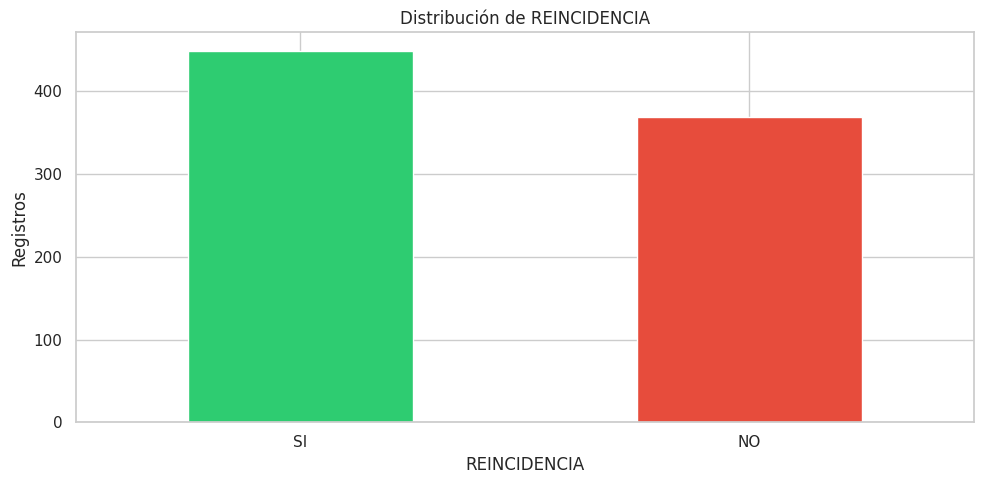

In [5]:
data['REINCIDENCIA'].value_counts().plot(kind='bar', color=['#2ecc71','#e74c3c'], edgecolor='white')
plt.title('Distribución de REINCIDENCIA')
plt.xticks(rotation=0)
plt.ylabel('Registros')
plt.tight_layout()
plt.show()

In [6]:
# Configuración de grupos de variables
objetivo = 'REINCIDENCIA'

# Variables con exactamente 2 categorías → drop_first=True
predictoras_2cat = [c for c in data.columns
                    if c != objetivo and data[c].nunique() == 2
                    and str(data[c].dtype) in ['object','category','bool','boolean']
                    or (data[c].nunique() == 2
                        and set(str(v) for v in data[c].dropna().unique())
                            .issubset({'SI','NO','True','False','1','0'}))]
predictoras_2cat = [c for c in predictoras_2cat if c != objetivo]

# Variables con más de 2 categorías → drop_first=False
predictoras_multicat = [c for c in data.select_dtypes(include=['object','category']).columns
                        if c != objetivo and data[c].nunique() > 2]

# Variables numéricas continuas
predictoras_numericas = [c for c in data.select_dtypes(include='number').columns
                         if c != objetivo]

print(f'2 categorías  ({len(predictoras_2cat)}):  {predictoras_2cat}')
print(f'Multicategoría ({len(predictoras_multicat)}): {predictoras_multicat}')
print(f'Numéricas      ({len(predictoras_numericas)}): {predictoras_numericas}')

2 categorías  (28):  ['SEXO', 'AREA_ DE_ RESIDENCIA', 'GESTANTE', 'POBLACION_ A _CARGO_ ICBF', 'CONFLICTO_ CON_ PAREJA_ O _EX_ PAREJA', 'ENFERMEDAD_ CRONICA_ DOLOROSA_ O_ DISCAPACITANTE', 'PROBLEMAS_ ECONOMICOS', 'MUERTE_ DE_ UN_ FAMILIAR', 'PROBLEMAS_ JURIDICOS', 'SUICIDIO_ DE_ UN_ FAMILIAR', 'MALTRATO_ FISICO_SICOLOGICO_SEXUAL', 'PROBLEMAS_ LABORALES', 'PROBLEMAS_ FAMILIARES', 'CONSUMO_ DE_ SPA', 'ANTECEDENTES_ FAMILIARES_ DE_ CONDUCTA_ SUICIDA', 'IDEACION_ SUICIDA_ PERSISTENTE_', 'PLAN_ ORGANIZADO_ DE _SUICIDIO', 'TRASTORNO_ DEPRESIVO', 'TRASTORNO_ DE_ PERSONALIDAD', 'TRASTORNO_ BIPOLAR', 'ESQUIZOFRENIA', 'ANTECEDENTE_ VIOLENCIA _O_ ABUSO', 'ABUSO_ DE_  ALCOHOL', 'AHORCAMIENTO', 'ARMA_ CORTOPUNZANTE', 'LANZAMIENTO_ AL_ VACIO', 'LANZAMIENTO_ A_ VEHICULO', 'INTOXICACIONES']
Multicategoría (4): ['SEGURIDAD_ SOCIAL', 'ESTRATO_SOCIOECONOMICO', 'ESTADO_CIVIL', 'ESCOLARIDAD']
Numéricas      (0): []


In [7]:
# Dummies para variables predictoras categóricas
if predictoras_multicat:
    data = pd.get_dummies(data, columns=predictoras_multicat, drop_first=False, dtype=int)
if predictoras_2cat:
    data = pd.get_dummies(data, columns=predictoras_2cat, drop_first=True, dtype=int)

# Convertir booleanas/SI-NO restantes a int
"""
for col in data.columns:
    if col == objetivo: continue
    if str(data[col].dtype) in ['bool','boolean']:
        data[col] = data[col].astype(int)
    elif set(data[col].dropna().unique()).issubset({'SI','NO'}):
        data[col] = data[col].map({'SI':1,'NO':0})
""" #Esto posiblemente no lo necesitamos

# LabelEncoder para la variable objetivo
labelencoder = LabelEncoder()
data[objetivo] = labelencoder.fit_transform(
    data[objetivo].map({'SI':'SI','NO':'NO',1:'SI',0:'NO',
                        True:'SI',False:'NO'}).fillna(data[objetivo].astype(str))
)

data.fillna(0, inplace=True)
print(f'Clases: {labelencoder.classes_}  →  {list(range(len(labelencoder.classes_)))}')
print(f'Shape tras preprocesamiento: {data.shape}')
data.head()

Clases: ['NO' 'SI']  →  [0, 1]
Shape tras preprocesamiento: (818, 54)


,REINCIDENCIA,SEGURIDAD_ SOCIAL_CONTRIBUTIVO,SEGURIDAD_ SOCIAL_ESPECIAL,SEGURIDAD_ SOCIAL_EXCEPCION,SEGURIDAD_ SOCIAL_INDETERMINADO,SEGURIDAD_ SOCIAL_NO ASEGURADO,SEGURIDAD_ SOCIAL_SUBSIDIADO,ESTRATO_SOCIOECONOMICO_1,ESTRATO_SOCIOECONOMICO_2,ESTRATO_SOCIOECONOMICO_3,ESTRATO_SOCIOECONOMICO_4,ESTRATO_SOCIOECONOMICO_5,ESTADO_CIVIL_CASADO/A,ESTADO_CIVIL_DIVORCIADO/A,ESTADO_CIVIL_SOLTERO/A,ESTADO_CIVIL_UNION LIBRE,ESTADO_CIVIL_VIUDO(A),ESCOLARIDAD_BASICA PRIMARIA,ESCOLARIDAD_BASICA SECUNDARIA,ESCOLARIDAD_ESPECIALIZACION,ESCOLARIDAD_MAESTRIA,ESCOLARIDAD_NINGUNO,ESCOLARIDAD_PREESCOLAR,ESCOLARIDAD_PROFESIONAL,ESCOLARIDAD_SIN INFORMACION,ESCOLARIDAD_TECNOLOGIA O TECNICA,SEXO_MASCULINO,AREA_ DE_ RESIDENCIA_RURAL DISPERSO,GESTANTE_SI,POBLACION_ A _CARGO_ ICBF_SI,CONFLICTO_ CON_ PAREJA_ O _EX_ PAREJA_SI,ENFERMEDAD_ CRONICA_ DOLOROSA_ O_ DISCAPACITANTE_SI,PROBLEMAS_ ECONOMICOS_SI,MUERTE_ DE_ UN_ FAMILIAR_SI,PROBLEMAS_ JURIDICOS_SI,SUICIDIO_ DE_ UN_ FAMILIAR_SI,MALTRATO_ FISICO_SICOLOGICO_SEXUAL_SI,PROBLEMAS_ LABORALES_SI,PROBLEMAS_ FAMILIARES_SI,CONSUMO_ DE_ SPA_SI,ANTECEDENTES_ FAMILIARES_ DE_ CONDUCTA_ SUICIDA_SI,IDEACION_ SUICIDA_ PERSISTENTE__SI,PLAN_ ORGANIZADO_ DE _SUICIDIO_SI,TRASTORNO_ DEPRESIVO_SI,TRASTORNO_ DE_ PERSONALIDAD_SI,TRASTORNO_ BIPOLAR_SI,ESQUIZOFRENIA_SI,ANTECEDENTE_ VIOLENCIA _O_ ABUSO_SI,ABUSO_ DE_ ALCOHOL_SI,AHORCAMIENTO_SI,ARMA_ CORTOPUNZANTE_SI,LANZAMIENTO_ AL_ VACIO_SI,LANZAMIENTO_ A_ VEHICULO_SI,INTOXICACIONES_SI
0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0
3,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1
4,1,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 818 entries, 0 to 817
Data columns (total 54 columns):
 #   Column                                               Non-Null Count  Dtype
---  ------                                               --------------  -----
 0   REINCIDENCIA                                         818 non-null    int64
 1   SEGURIDAD_ SOCIAL_CONTRIBUTIVO                       818 non-null    int64
 2   SEGURIDAD_ SOCIAL_ESPECIAL                           818 non-null    int64
 3   SEGURIDAD_ SOCIAL_EXCEPCION                          818 non-null    int64
 4   SEGURIDAD_ SOCIAL_INDETERMINADO                      818 non-null    int64
 5   SEGURIDAD_ SOCIAL_NO ASEGURADO                       818 non-null    int64
 6   SEGURIDAD_ SOCIAL_SUBSIDIADO                         818 non-null    int64
 7   ESTRATO_SOCIOECONOMICO_1                             818 non-null    int64
 8   ESTRATO_SOCIOECONOMICO_2                             818 non-null    int64
 9   ESTRATO_SO

# 2. División de datos

El orden correcto es:
1. **Dividir primero** en 70% train y 30% test
2. **Normalizar** si es necesario

In [9]:
X = data.drop(objetivo, axis=1)
Y = data[objetivo]

# División 70-30 estratificada
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, stratify=Y, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]} registros')
print(f'  Balance: {Y_train.mean()*100:.1f}% positivos')
print(f'Test:      {X_test.shape[0]} registros')
print(f'  Balance: {Y_test.mean()*100:.1f}% positivos')

Train: 572 registros
  Balance: 54.9% positivos
Test:      246 registros
  Balance: 54.9% positivos


In [10]:
# Validación cruzada estratificada — 10 folds
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# Métricas a evaluar — macro para tratar las clases equitativamente
scoring = ('f1_macro', 'precision_macro', 'recall_macro', 'roc_auc')

# DataFrame para acumular los test_f1_macro de cada modelo (usado en ANOVA)
comparacion_CV = pd.DataFrame()

print('Configuración lista:')
print(f'  10-fold StratifiedKFold')
print(f'  Métricas: {scoring}')
print(f'  cross_validate con return_train_score=True → permite detectar sobreentrenamiento')

Configuración lista:
  10-fold StratifiedKFold
  Métricas: ('f1_macro', 'precision_macro', 'recall_macro', 'roc_auc')
  cross_validate con return_train_score=True → permite detectar sobreentrenamiento


# 3. Clasificadores individuales

## Regresión Logística

Modelo lineal interpretable, ideal como línea base en clasificación binaria.
`class_weight='balanced'` ajusta los pesos de clase para compensar el desbalance residual.
`C` controla la regularización L2: valores pequeños penalizan más los coeficientes.

In [11]:
model_lr = LogisticRegression(
    C=0.1,
    solver='lbfgs',
    penalty='l2',
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

scores_lr = cross_validate(model_lr, X_train, Y_train, cv=cv,
                           scoring=scoring, return_train_score=True)
scores_lr = pd.DataFrame(scores_lr)
print('=== Regresión Logística — scores por fold ===')
print(scores_lr.to_string())
print('\n--- Promedios (cuidado si train >> test: sobreentrenamiento) ---')
print(scores_lr.mean().round(4).to_string())

# Acumular F1 de test para comparación estadística posterior
comparacion_CV['Reg. Logística'] = scores_lr['test_f1_macro']

=== Regresión Logística — scores por fold ===
   fit_time  score_time  test_f1_macro  train_f1_macro  test_precision_macro  train_precision_macro  test_recall_macro  train_recall_macro  test_roc_auc  train_roc_auc
0  0.027133    0.027113       0.533234        0.688036              0.547205               0.688908           0.545673            0.690710      0.507212       0.758239
1  0.038735    0.023334       0.654762        0.692043              0.657143               0.693201           0.658654            0.695020      0.659856       0.750015
2  0.020576    0.018843       0.643750        0.684808              0.643750               0.685720           0.643750            0.687411      0.657500       0.746690
3  0.016886    0.016163       0.698413        0.689122              0.697891               0.691828           0.699375            0.693194      0.752500       0.738989
4  0.011127    0.013739       0.594494        0.694588              0.594444               0.695855           0.59

Tiempo de ejecución: 0.02 segundos
=== Evaluación en TEST (datos reales, sin SMOTE) ===
              precision    recall  f1-score   support

          NO       0.61      0.57      0.59       111
          SI       0.66      0.70      0.68       135

    accuracy                           0.64       246
   macro avg       0.64      0.64      0.64       246
weighted avg       0.64      0.64      0.64       246



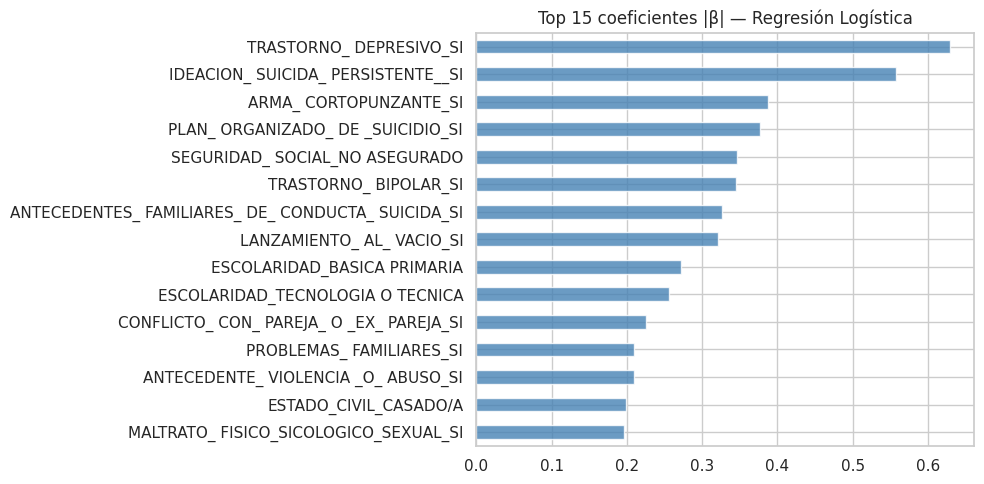

In [12]:
# Entrenar con todos los datos de entrenamiento para evaluar en test

import time

inicio = time.time()



model_lr.fit(X_train, Y_train)
Y_pred = model_lr.predict(X_test)

fin = time.time()
print(f'Tiempo de ejecución: {fin - inicio:.2f} segundos')
print('=== Evaluación en TEST (datos reales, sin SMOTE) ===')
print(metrics.classification_report(Y_test, Y_pred, target_names=labelencoder.classes_))

# Gráfico de coeficientes
coef_df = pd.Series(np.abs(model_lr.coef_[0]), index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(10,5))
coef_df.head(15).sort_values().plot(kind='barh', color='steelblue', alpha=0.8)
plt.title('Top 15 coeficientes |β| — Regresión Logística')
plt.tight_layout()
plt.show()

##SVM para clasificación

In [13]:
# ── SVM (Support Vector Machine) ─────────────────────────────────────────
# Justificación: encuentra el hiperplano de máximo margen entre clases.
# Robusto al sobreentrenamiento porque optimiza el margen en lugar de
# memorizar los datos — a diferencia de KNN que memoriza directamente.
# kernel='rbf' maneja relaciones no lineales entre variables binarias.
# class_weight='balanced' ajusta los pesos por el leve desbalance residual.
# probability=True es necesario para obtener predict_proba (curva ROC).

from sklearn.svm import SVC

model_svm = SVC(
    kernel='linear',            # Función de base radial — captura relaciones no lineales
    C=0.03,                     # Penalización por error — valores altos: menor margen, más ajuste
    gamma='scale',           # Escala automática: 1 / (n_features * X.var())
    class_weight='balanced', # Pesos inversamente proporcionales a frecuencias de clase
    probability=True,        # Habilita predict_proba para calcular AUC-ROC
    random_state=RANDOM_STATE
)

scores_svm = cross_validate(model_svm, X_train, Y_train, cv=cv,
                            scoring=scoring, return_train_score=True)
scores_svm = pd.DataFrame(scores_svm)
print('=== SVM — scores por fold ===')
print(scores_svm.to_string())
print('\n--- Promedios (cuidado si train >> test: sobreentrenamiento) ---')
print(scores_svm.mean().round(4).to_string())

comparacion_CV['SVM'] = scores_svm['test_f1_macro']

=== SVM — scores por fold ===
   fit_time  score_time  test_f1_macro  train_f1_macro  test_precision_macro  train_precision_macro  test_recall_macro  train_recall_macro  test_roc_auc  train_roc_auc
0  0.065726    0.012947       0.482759        0.649466              0.487981               0.651695           0.487981            0.652956      0.519231       0.742205
1  0.056551    0.012097       0.620238        0.657401              0.633578               0.668074           0.631010            0.666162      0.664663       0.733691
2  0.075101    0.015789       0.594494        0.679568              0.595443               0.683979           0.596875            0.684702      0.666250       0.731181
3  0.102081    0.021959       0.681762        0.669623              0.681481               0.681471           0.683750            0.678819      0.752500       0.724789
4  0.143924    0.026623       0.648148        0.654368              0.648399               0.660533           0.649504            

In [14]:
inicio = time.time()

model_svm.fit(X_train, Y_train)
Y_pred = model_svm.predict(X_test)
fin = time.time()
print(f'Tiempo de ejecución: {fin - inicio:.2f} segundos')

print('=== Evaluación en TEST ===')
print(metrics.classification_report(Y_test, Y_pred, target_names=labelencoder.classes_))

Tiempo de ejecución: 0.31 segundos
=== Evaluación en TEST ===
              precision    recall  f1-score   support

          NO       0.61      0.60      0.61       111
          SI       0.68      0.69      0.68       135

    accuracy                           0.65       246
   macro avg       0.65      0.65      0.65       246
weighted avg       0.65      0.65      0.65       246



## K-Nearest Neighbors (KNN)

Clasifica por similitud con los k casos más cercanos del histórico.
`weights='distance'` da más peso a los vecinos más próximos.
`metric='minkowski'` con `p=2` equivale a la distancia euclidiana.

**SUPER SOBREAJUSTADO, CREO QUE TENEMOS MUCHAS DIMENSIONES**

In [15]:
model_knn = KNeighborsClassifier(
    n_neighbors=11,
    weights='uniform',
    metric='euclidean',
    p=1,
    algorithm='auto',
    leaf_size=30
)

scores_knn = cross_validate(model_knn, X_train, Y_train, cv=cv,
                            scoring=scoring, return_train_score=True)
scores_knn = pd.DataFrame(scores_knn)
print('=== KNN — scores por fold ===')
print(scores_knn.to_string())
print('\n--- Promedios ---')
print(scores_knn.mean().round(4).to_string())

comparacion_CV['KNN'] = scores_knn['test_f1_macro']

=== KNN — scores por fold ===
   fit_time  score_time  test_f1_macro  train_f1_macro  test_precision_macro  train_precision_macro  test_recall_macro  train_recall_macro  test_roc_auc  train_roc_auc
0  0.017892    0.153110       0.549582        0.693360              0.550000               0.693524           0.550481            0.693217      0.584736       0.766630
1  0.009614    0.057548       0.543030        0.679726              0.544118               0.679799           0.543269            0.679659      0.606370       0.755801
2  0.024864    0.118032       0.583677        0.697521              0.587013               0.698116           0.583750            0.697121      0.674375       0.749886
3  0.025476    0.097209       0.681762        0.690401              0.681481               0.690401           0.683750            0.690401      0.701875       0.737132
4  0.024694    0.097456       0.460227        0.708799              0.461688               0.709729           0.463400            

In [16]:
inicio = time.time()
model_knn.fit(X_train, Y_train)
Y_pred = model_knn.predict(X_test)
fin = time.time()
print(f'Tiempo de ejecución: {fin - inicio:.2f} segundos')
print('=== Evaluación en TEST ===')
print(metrics.classification_report(Y_test, Y_pred, target_names=labelencoder.classes_))

Tiempo de ejecución: 0.02 segundos
=== Evaluación en TEST ===
              precision    recall  f1-score   support

          NO       0.52      0.52      0.52       111
          SI       0.60      0.60      0.60       135

    accuracy                           0.57       246
   macro avg       0.56      0.56      0.56       246
weighted avg       0.57      0.57      0.57       246



## Árbol de Decisión

Genera reglas interpretables directamente aplicables en contexto clínico.
`ccp_alpha` aplica poda post-entrenamiento para reducir sobreentrenamiento.
`criterion='gini'` mide la impureza de cada nodo.

In [17]:
model_dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=15,
    class_weight=None,
    ccp_alpha=0.001,
    random_state=RANDOM_STATE
)

scores_dt = cross_validate(model_dt, X_train, Y_train, cv=cv,
                           scoring=scoring, return_train_score=True)
scores_dt = pd.DataFrame(scores_dt)
print('=== Árbol de Decisión — scores por fold ===')
print(scores_dt.to_string())
print('\n--- Promedios ---')
print(scores_dt.mean().round(4).to_string())

comparacion_CV['Árbol'] = scores_dt['test_f1_macro']

=== Árbol de Decisión — scores por fold ===
   fit_time  score_time  test_f1_macro  train_f1_macro  test_precision_macro  train_precision_macro  test_recall_macro  train_recall_macro  test_roc_auc  train_roc_auc
0  0.016716    0.032229       0.414141        0.672011              0.416667               0.696077           0.427885            0.673132      0.448317       0.748212
1  0.010884    0.032520       0.616587        0.663531              0.616587               0.663327           0.616587            0.664466      0.691106       0.716763
2  0.007519    0.026543       0.676136        0.661829              0.679028               0.661591           0.675000            0.662314      0.727500       0.729956
3  0.007940    0.023930       0.619879        0.664055              0.624026               0.676096           0.619375            0.664003      0.659375       0.718070
4  0.008296    0.021659       0.583677        0.660535              0.591270               0.670757           0.5856

Tiempo de ejecución: 0.03 segundos
=== Evaluación en TEST ===
              precision    recall  f1-score   support

          NO       0.65      0.41      0.51       111
          SI       0.63      0.81      0.71       135

    accuracy                           0.63       246
   macro avg       0.64      0.61      0.61       246
weighted avg       0.64      0.63      0.62       246



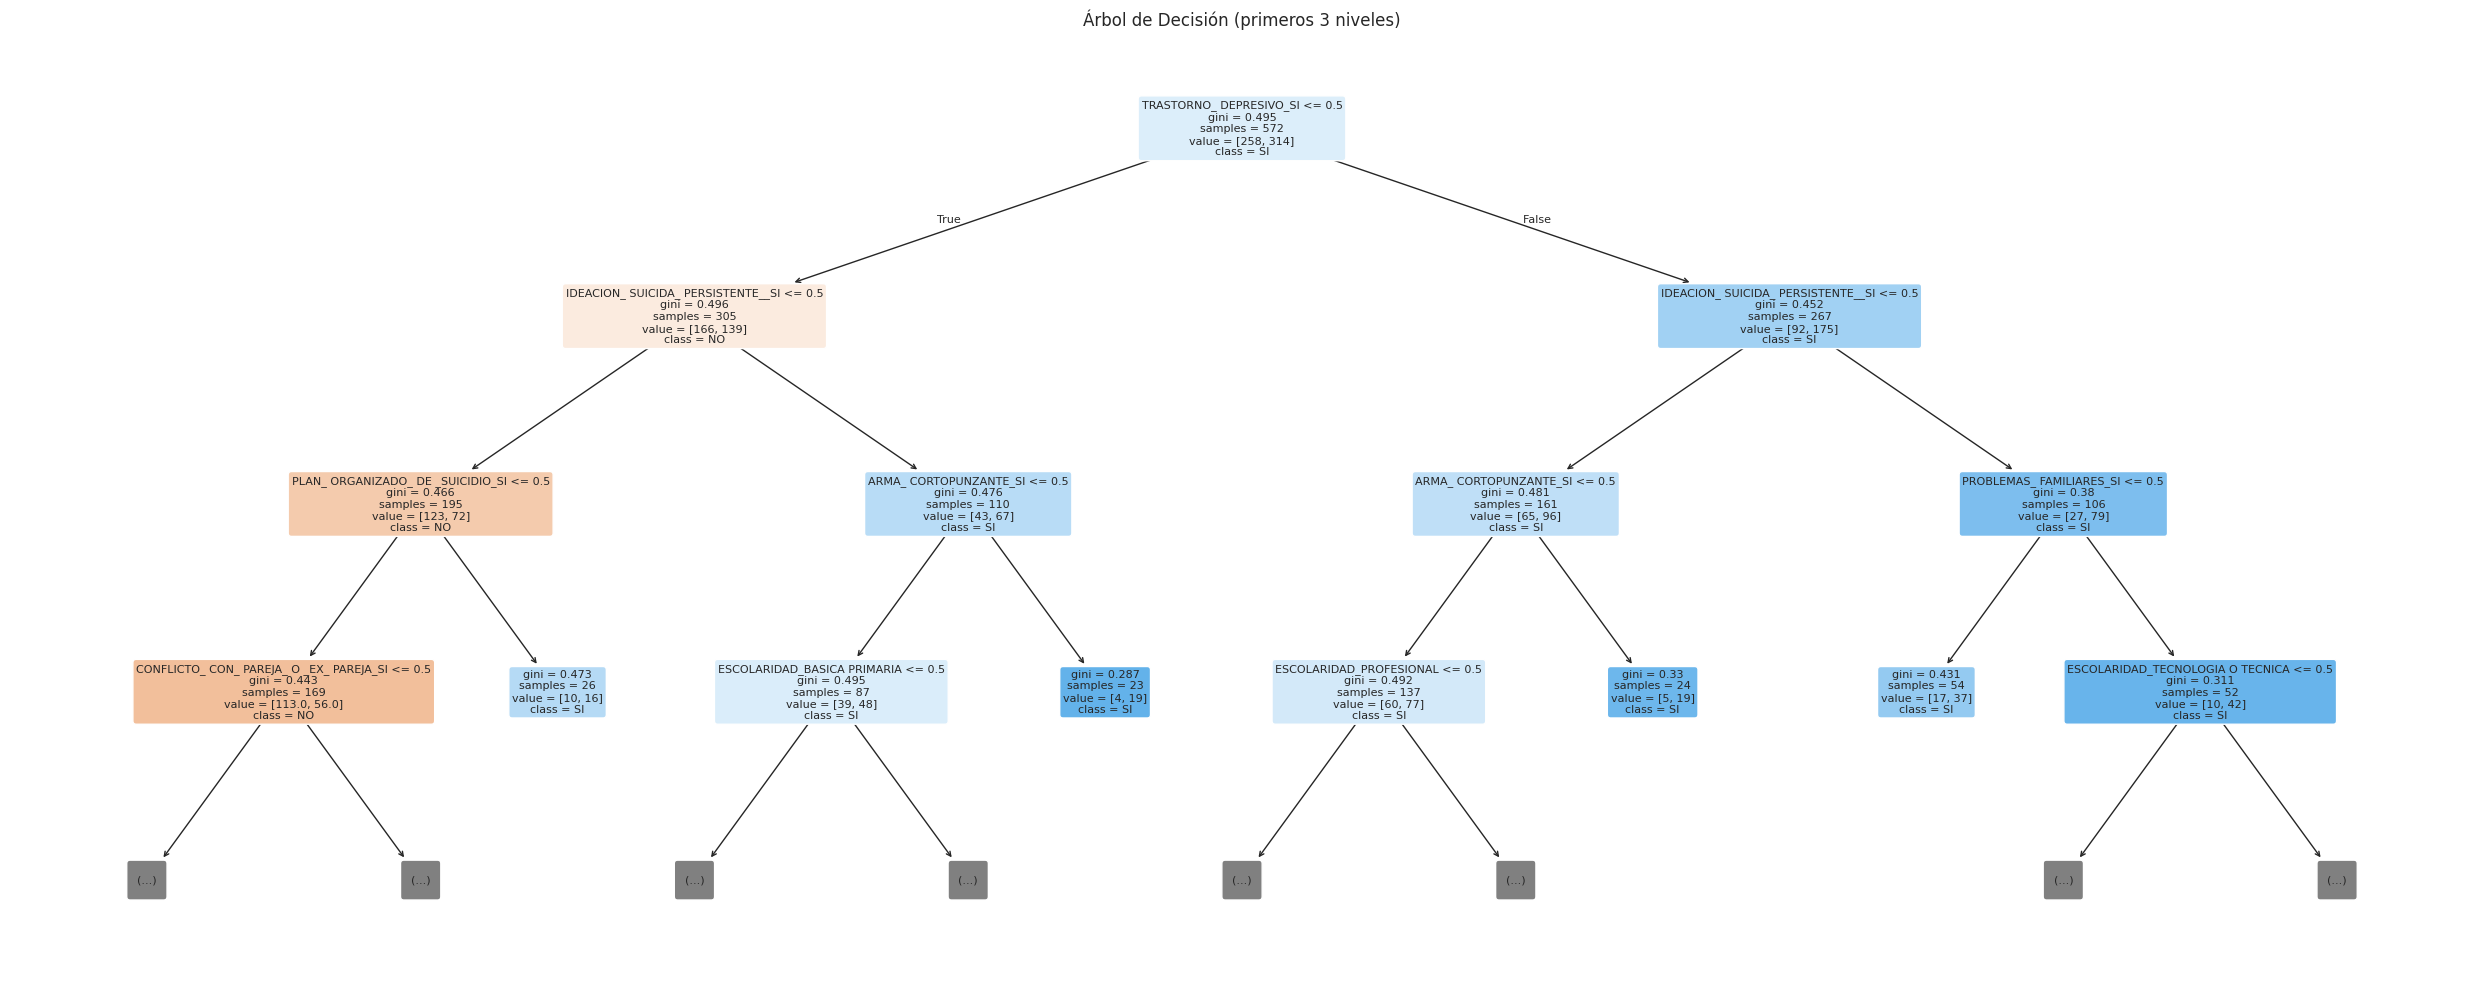

In [18]:
inicio = time.time()
model_dt.fit(X_train, Y_train)
Y_pred = model_dt.predict(X_test)
fin = time.time()
print(f'Tiempo de ejecución: {fin - inicio:.2f} segundos')
print('=== Evaluación en TEST ===')
print(metrics.classification_report(Y_test, Y_pred, target_names=labelencoder.classes_))

# Visualización del árbol
plt.figure(figsize=(25, 10))
plot_tree(model_dt, max_depth=3, feature_names=X_train.columns.values,
          class_names=labelencoder.classes_, rounded=True, filled=True, fontsize=8)
plt.title('Árbol de Decisión (primeros 3 niveles)')
plt.tight_layout()
plt.show()

## Naive Bayes Bernoulli

Diseñado para variables binarias (distribución de Bernoulli), que predominan
en este dataset. Calcula la probabilidad de reincidencia dado el conjunto de
factores de riesgo. Extremadamente eficiente computacionalmente.

In [19]:
model_nb = BernoulliNB(
    alpha=1.0,
    binarize=0.5,
    fit_prior=True
)

scores_nb = cross_validate(model_nb, X_train, Y_train, cv=cv,
                           scoring=scoring, return_train_score=True)
scores_nb = pd.DataFrame(scores_nb)
print('=== Naive Bayes — scores por fold ===')
print(scores_nb.to_string())
print('\n--- Promedios ---')
print(scores_nb.mean().round(4).to_string())

comparacion_CV['Naive Bayes'] = scores_nb['test_f1_macro']

=== Naive Bayes — scores por fold ===
   fit_time  score_time  test_f1_macro  train_f1_macro  test_precision_macro  train_precision_macro  test_recall_macro  train_recall_macro  test_roc_auc  train_roc_auc
0  0.028434    0.020797       0.551724        0.682296              0.557692               0.683559           0.557692            0.681676      0.500000       0.750963
1  0.018165    0.048819       0.578182        0.698887              0.579657               0.699374           0.578125            0.698536      0.627404       0.750978
2  0.006657    0.017465       0.577778        0.697952              0.585811               0.700452           0.579375            0.697029      0.603750       0.748455
3  0.015167    0.042561       0.679375        0.689399              0.679375               0.690230           0.679375            0.688910      0.773750       0.739385
4  0.022937    0.018229       0.588383        0.682158              0.591432               0.684146           0.588710    

In [20]:
inicio = time.time()
model_nb.fit(X_train, Y_train)
Y_pred = model_nb.predict(X_test)
fin = time.time()
print(f'Tiempo de ejecución: {fin - inicio:.2f} segundos')

print('=== Evaluación en TEST ===')
print(metrics.classification_report(Y_test, Y_pred, target_names=labelencoder.classes_))

Tiempo de ejecución: 0.01 segundos
=== Evaluación en TEST ===
              precision    recall  f1-score   support

          NO       0.62      0.51      0.56       111
          SI       0.65      0.74      0.69       135

    accuracy                           0.64       246
   macro avg       0.63      0.63      0.63       246
weighted avg       0.64      0.64      0.63       246



#Red neuronal

In [21]:
from sklearn.neural_network import MLPClassifier #MLPRegressor

#Solo se configura capas ocultas, no se configura capa de entrada y de salida
#activation -> función activación de la oculta: tanh, logistic, linear, relu
#hidden_layer_sizes=5,7 -> dos capas ocultas con 5 neuronas y 7 neuronas
#learning_rate-> tamaño del paso constante o decreciente (constant, adaptive)
#learning_rate_init-> valor tasa de aprendizaje
#momentum-> valor momentum
#max_iter-> iteaciones
#random_state-> semilla para generacion numeros seudoaletorios
modelNN = MLPClassifier(activation="logistic",hidden_layer_sizes=(50), learning_rate='adaptive',
                     learning_rate_init=0.02, momentum= 0.03, max_iter=500, random_state=3)
inicio = time.time()
modelNN.fit(X_train, Y_train)
fin = time.time()
print(f'Tiempo de ejecución: {fin - inicio:.2f} segundos')

Tiempo de ejecución: 1.56 segundos


In [22]:
scores_NN = cross_validate(modelNN, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores_NN=pd.DataFrame(scores_NN) #Se almacenan los resultados en un dataframe

print('=== Red neuronal — scores por fold ===')
print(scores_NN.to_string())
print('\n--- Promedios ---')
print(scores_NN.mean().round(4).to_string())

=== Red neuronal — scores por fold ===
   fit_time  score_time  test_f1_macro  train_f1_macro  test_precision_macro  train_precision_macro  test_recall_macro  train_recall_macro  test_roc_auc  train_roc_auc
0  2.296807    0.046563       0.559928        0.979479              0.573284               0.978505           0.571171            0.980899      0.591592       0.999143
1  2.381884    0.063632       0.482690        0.980739              0.485897               0.982402           0.486787            0.979452      0.522823       0.999251
2  3.815005    0.024112       0.585119        0.975236              0.587955               0.976881           0.588589            0.973965      0.590991       0.998677
3  2.343558    0.019601       0.565349        0.979382              0.566789               0.980464           0.565465            0.978483      0.598799       0.999113
4  2.173172    0.021417       0.607656        0.978074              0.607633               0.977619           0.608408   

In [23]:
comparacion_CV['Red neuronal'] = scores_NN['test_f1_macro']

# 4. Métodos de ensamble

## Random Forest

Bagging de árboles con muestreo aleatorio de registros y variables.
`max_features='sqrt'` fuerza diversidad entre árboles.
`max_samples=0.8` cada árbol usa el 80% de los datos balanceados.

In [24]:
model_rf = RandomForestClassifier(
    n_estimators=200,          # 500 es innecesario y más lento, 200 es suficiente
    criterion='gini',
    max_depth=2,               # ← límite de profundidad, clave para evitar sobreajuste
                               # None permitía árboles perfectos en train
    min_samples_split=20,      # ← subir de 5 a 20: nodos con pocos datos no se dividen
    min_samples_leaf=10,       # ← subir de 2 a 10: hojas con más registros, menos ruido
    max_features='sqrt',
    max_samples=0.7,           # ← bajar de 0.8 a 0.7: más diversidad entre árboles
    bootstrap=True,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

scores_rf = cross_validate(model_rf, X_train, Y_train, cv=cv,
                           scoring=scoring, return_train_score=True)
scores_rf = pd.DataFrame(scores_rf)
print('=== Random Forest — scores por fold ===')
print(scores_rf.to_string())
print('\n--- Promedios ---')
print(scores_rf.mean().round(4).to_string())

comparacion_CV['Random Forest'] = scores_rf['test_f1_macro']

=== Random Forest — scores por fold ===
   fit_time  score_time  test_f1_macro  train_f1_macro  test_precision_macro  train_precision_macro  test_recall_macro  train_recall_macro  test_roc_auc  train_roc_auc
0  0.625168    0.192821       0.482143        0.673584              0.484524               0.673467           0.484375            0.674859      0.503606       0.749251
1  0.430798    0.110644       0.568837        0.686769              0.572879               0.692996           0.573317            0.693140      0.680288       0.725964
2  0.442134    0.109803       0.604167        0.664957              0.606138               0.665239           0.603750            0.666697      0.652500       0.725923
3  0.425064    0.109115       0.681762        0.684808              0.681481               0.685720           0.683750            0.687411      0.763750       0.720482
4  0.418375    0.121791       0.556489        0.677879              0.556875               0.680233           0.556452  

Tiempo de ejecución: 0.48 segundos
=== Evaluación en TEST ===
              precision    recall  f1-score   support

          NO       0.65      0.60      0.63       111
          SI       0.69      0.73      0.71       135

    accuracy                           0.67       246
   macro avg       0.67      0.67      0.67       246
weighted avg       0.67      0.67      0.67       246



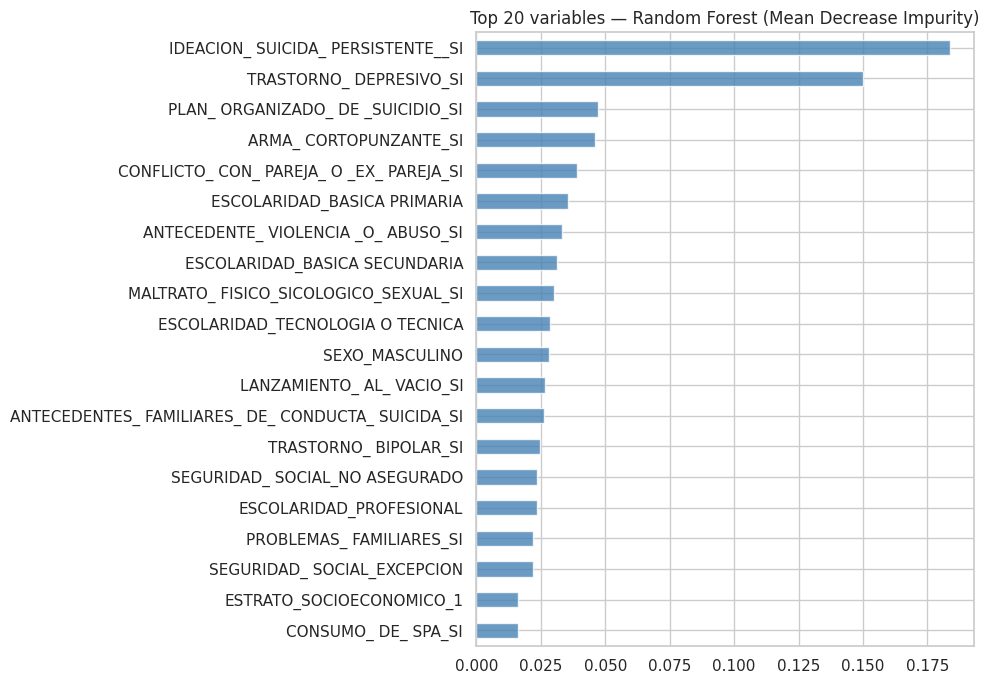

In [25]:
inicio = time.time()
model_rf.fit(X_train, Y_train)
Y_pred = model_rf.predict(X_test)
fin = time.time()
print(f'Tiempo de ejecución: {fin - inicio:.2f} segundos')
print('=== Evaluación en TEST ===')
print(metrics.classification_report(Y_test, Y_pred, target_names=labelencoder.classes_))

# Importancia de variables
imp_rf = pd.Series(model_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 7))
imp_rf.head(20).sort_values().plot(kind='barh', color='steelblue', alpha=0.8)
plt.title('Top 20 variables — Random Forest (Mean Decrease Impurity)')
plt.tight_layout()
plt.show()

## XGBoost

Gradient Boosting extremo con regularización L1/L2 integrada.
Construye árboles en cascada donde cada uno corrige errores del anterior.
`scale_pos_weight` ajusta el peso de la clase positiva para el desbalance.

In [26]:
scale_pos = (Y_train == 0).sum() / (Y_train == 1).sum()

model_xgb = XGBClassifier(
    n_estimators=80,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    colsample_bylevel=0.8,
    min_child_weight=3,
    gamma=0.5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    verbosity=0,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

scores_xgb = cross_validate(model_xgb, X_train, Y_train, cv=cv,
                            scoring=scoring, return_train_score=True)
scores_xgb = pd.DataFrame(scores_xgb)
print('=== XGBoost — scores por fold ===')
print(scores_xgb.to_string())
print('\n--- Promedios ---')
print(scores_xgb.mean().round(4).to_string())

comparacion_CV['XGBoost'] = scores_xgb['test_f1_macro']

=== XGBoost — scores por fold ===
   fit_time  score_time  test_f1_macro  train_f1_macro  test_precision_macro  train_precision_macro  test_recall_macro  train_recall_macro  test_roc_auc  train_roc_auc
0  0.809961    0.050467       0.480287        0.681356              0.480952               0.683729           0.480769            0.680530      0.490986       0.757574
1  0.103673    0.035822       0.597587        0.664510              0.598182               0.664356           0.597356            0.664710      0.706731       0.738873
2  0.151736    0.045320       0.659969        0.668197              0.660985               0.668607           0.659375            0.667915      0.688750       0.738471
3  0.107791    0.027612       0.698413        0.659049              0.697891               0.659049           0.699375            0.659049      0.758750       0.732901
4  0.197500    0.024234       0.552590        0.666365              0.554987               0.668218           0.553350        

Tiempo de ejecución: 0.05 segundos
=== Evaluación en TEST ===
              precision    recall  f1-score   support

          NO       0.64      0.49      0.55       111
          SI       0.65      0.78      0.71       135

    accuracy                           0.65       246
   macro avg       0.65      0.63      0.63       246
weighted avg       0.65      0.65      0.64       246



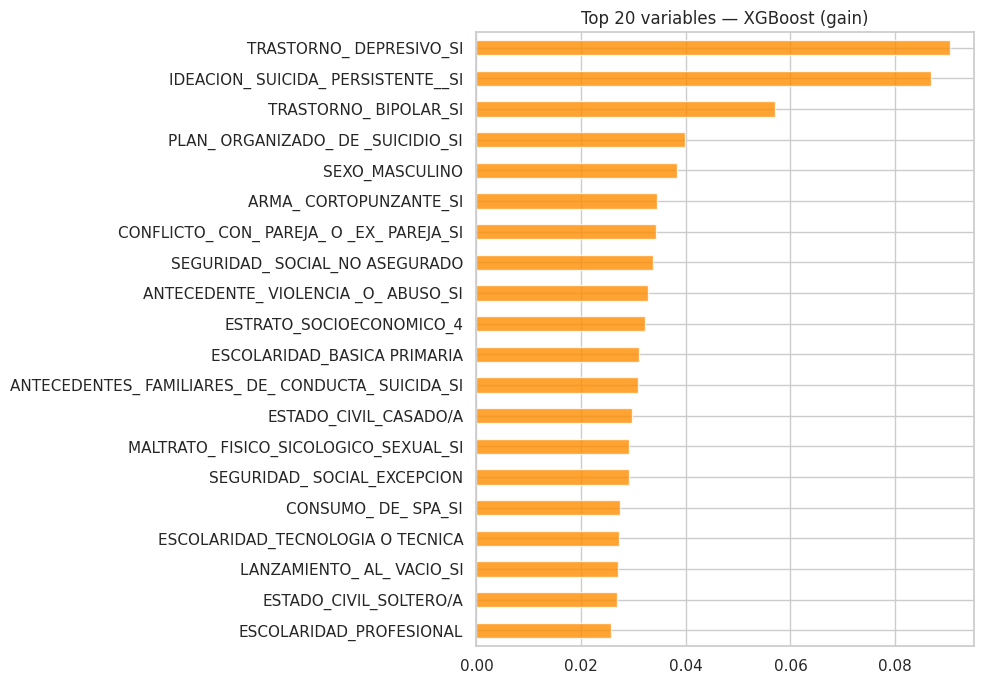

In [27]:
inicio = time.time()
model_xgb.fit(X_train, Y_train)
Y_pred = model_xgb.predict(X_test)
fin = time.time()
print(f'Tiempo de ejecución: {fin - inicio:.2f} segundos')
print('=== Evaluación en TEST ===')
print(metrics.classification_report(Y_test, Y_pred, target_names=labelencoder.classes_))

imp_xgb = pd.Series(model_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 7))
imp_xgb.head(20).sort_values().plot(kind='barh', color='darkorange', alpha=0.8)
plt.title('Top 20 variables — XGBoost (gain)')
plt.tight_layout()
plt.show()

## Votación Soft

Combina las probabilidades de LR, RF y XGBoost con pesos manuales.
RF y XGBoost reciben doble peso por su mejor desempeño individual.
Produce predicciones más estables al promediar las incertidumbres de cada modelo.

In [28]:
from sklearn.calibration import CalibratedClassifierCV

#model_nb_cal = CalibratedClassifierCV(model_nb, method='isotonic', cv=5)

model_soft = VotingClassifier(
    estimators=[('lr', model_lr), ('nb', model_nb), ('rf', model_rf)],
    voting='soft',
    weights=[3, 2, 1]
)

scores_soft = cross_validate(model_soft, X_train, Y_train, cv=cv,
                             scoring=scoring, return_train_score=True)
scores_soft = pd.DataFrame(scores_soft)
print('=== Votación Soft — scores por fold ===')
print(scores_soft.to_string())
print('\n--- Promedios ---')
print(scores_soft.mean().round(4).to_string())

comparacion_CV['Votación Soft'] = scores_soft['test_f1_macro']

=== Votación Soft — scores por fold ===
   fit_time  score_time  test_f1_macro  train_f1_macro  test_precision_macro  train_precision_macro  test_recall_macro  train_recall_macro  test_roc_auc  train_roc_auc
0  0.476667    0.109973       0.586207        0.694048              0.592548               0.693818           0.592548            0.694363      0.513221       0.758284
1  0.490700    0.119239       0.546875        0.698743              0.546875               0.698437           0.546875            0.699820      0.644231       0.753439
2  0.471622    0.107399       0.619879        0.694757              0.624026               0.694533           0.619375            0.695066      0.642500       0.750875
3  0.472972    0.129720       0.679375        0.695682              0.679375               0.695473           0.679375            0.696930      0.766250       0.743037
4  0.467325    0.128555       0.627451        0.706077              0.628125               0.705934           0.627171  

In [29]:
inicio = time.time()
model_soft.fit(X_train, Y_train)
Y_pred = model_soft.predict(X_test)
fin = time.time()
print(f'Tiempo de ejecución: {fin - inicio:.2f} segundos')
print('=== Evaluación en TEST ===')
print(metrics.classification_report(Y_test, Y_pred, target_names=labelencoder.classes_))

Tiempo de ejecución: 0.51 segundos
=== Evaluación en TEST ===
              precision    recall  f1-score   support

          NO       0.64      0.55      0.59       111
          SI       0.67      0.75      0.71       135

    accuracy                           0.66       246
   macro avg       0.66      0.65      0.65       246
weighted avg       0.66      0.66      0.65       246



# 5. Comparación de modelos

In [30]:
# Tabla completa de F1-macro por fold para todos los modelos
print('=== comparacion_CV (F1-macro por fold) ===')
print(comparacion_CV.to_string())
print('\n--- Promedios ---')
print(comparacion_CV.mean().round(4).sort_values(ascending=False).to_string())

=== comparacion_CV (F1-macro por fold) ===
   Reg. Logística       SVM       KNN     Árbol  Naive Bayes  Red neuronal  Random Forest   XGBoost  Votación Soft
0        0.533234  0.482759  0.549582  0.414141     0.551724      0.559928       0.482143  0.480287       0.586207
1        0.654762  0.620238  0.543030  0.616587     0.578182      0.482690       0.568837  0.597587       0.546875
2        0.643750  0.594494  0.583677  0.676136     0.577778      0.585119       0.604167  0.659969       0.619879
3        0.698413  0.681762  0.681762  0.619879     0.679375      0.565349       0.681762  0.698413       0.679375
4        0.594494  0.648148  0.460227  0.583677     0.588383      0.607656       0.556489  0.552590       0.627451
5        0.559233  0.542593  0.646402  0.594494     0.572500      0.526444       0.543719  0.612963       0.560863
6        0.718519  0.666256  0.614493  0.532197     0.692283      0.655255       0.679375  0.635550       0.712121
7        0.525732  0.485528  0.543719

##Comparación por Recall

In [31]:
modelos_dict = {
    'Reg. Logística': model_lr,
    'KNN':            model_knn,
    'Árbol':          model_dt,
    'Naive Bayes':    model_nb,
    'Random Forest':  model_rf,
    'XGBoost':        model_xgb,
    'Votación Soft':  model_soft,
    'SVM':            model_svm,
    'Red neuronal':  modelNN
}

print('=== Valores de Recall (macro promedio) para todos los modelos en el conjunto de prueba ===')
recall_scores = {}
for nombre, modelo in modelos_dict.items():
    Y_pred = modelo.predict(X_test)
    recall = metrics.recall_score(Y_test, Y_pred, average='macro')
    recall_scores[nombre] = recall

# Sort and print the recall scores
for nombre, score in sorted(recall_scores.items(), key=lambda item: item[1], reverse=True):
    print(f"{nombre:<18}: {score:.4f}")

=== Valores de Recall (macro promedio) para todos los modelos en el conjunto de prueba ===
Random Forest     : 0.6685
Votación Soft     : 0.6488
SVM               : 0.6462
Reg. Logística    : 0.6356
XGBoost           : 0.6321
Naive Bayes       : 0.6271
Árbol             : 0.6146
Red neuronal      : 0.5729
KNN               : 0.5613


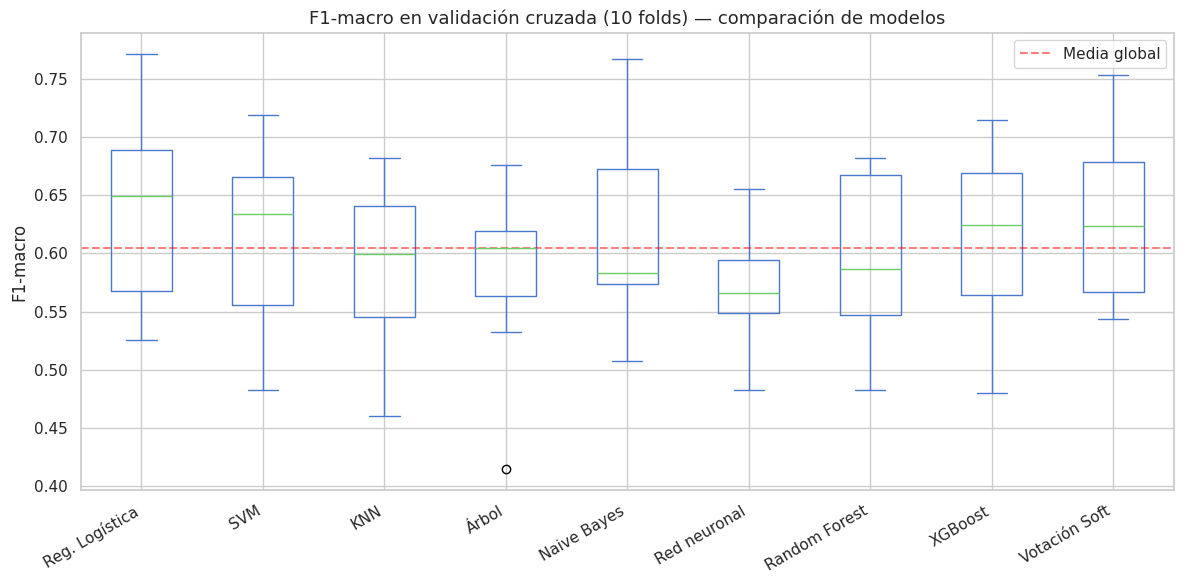

In [32]:
# Boxplot comparativo
comparacion_CV.plot(kind='box', figsize=(12, 6))
plt.title('F1-macro en validación cruzada (10 folds) — comparación de modelos', fontsize=13)
plt.ylabel('F1-macro')
plt.xticks(rotation=30, ha='right')
plt.axhline(y=comparacion_CV.values.mean(), color='red', linestyle='--', alpha=0.5, label='Media global')
plt.legend()
plt.tight_layout()
plt.show()

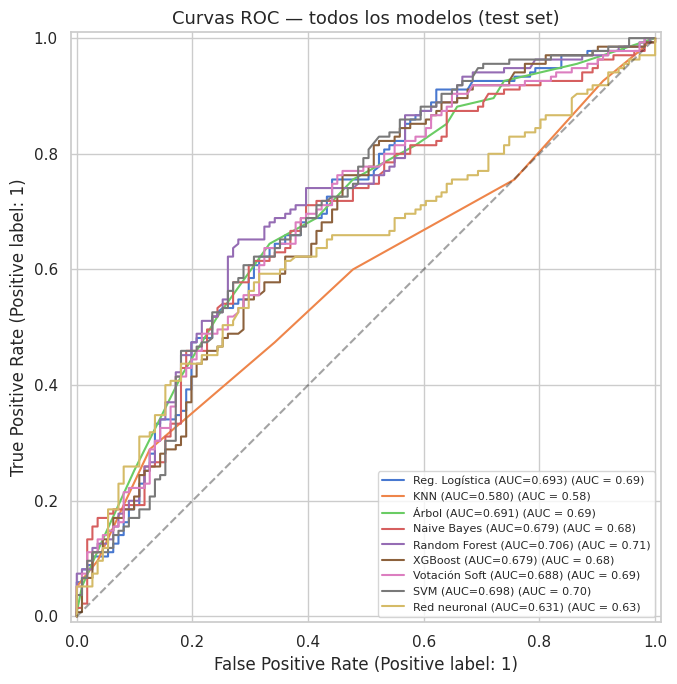

In [33]:
# Curvas ROC de todos los modelos (evaluadas en test)

fig, ax = plt.subplots(figsize=(9, 7))
for nombre, modelo in modelos_dict.items():
    y_proba = modelo.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(Y_test, y_proba)
    RocCurveDisplay.from_predictions(Y_test, y_proba,
                                     name=f'{nombre} (AUC={auc:.3f})', ax=ax)
ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set_title('Curvas ROC — todos los modelos (test set)', fontsize=13)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

In [34]:
print('=== Valores AUC-ROC para todos los modelos en el conjunto de prueba ===')
roc_auc_scores = {}
for nombre, modelo in modelos_dict.items():
    if hasattr(modelo, 'predict_proba'):
        y_proba = modelo.predict_proba(X_test)[:, 1]
        auc_score = roc_auc_score(Y_test, y_proba)
        roc_auc_scores[nombre] = auc_score
    else:
        # Some models (like SVC without probability=True) might not have predict_proba
        # For this notebook, SVM was set with probability=True, so this might not be hit.
        print(f"El modelo {nombre} no tiene el método predict_proba y no se puede calcular AUC-ROC.")

# Sort and print the ROC AUC scores
for nombre, auc_score in sorted(roc_auc_scores.items(), key=lambda item: item[1], reverse=True):
    print(f"{nombre:<18}: {auc_score:.4f}")

=== Valores AUC-ROC para todos los modelos en el conjunto de prueba ===
Random Forest     : 0.7062
SVM               : 0.6979
Reg. Logística    : 0.6926
Árbol             : 0.6913
Votación Soft     : 0.6876
Naive Bayes       : 0.6789
XGBoost           : 0.6788
Red neuronal      : 0.6314
KNN               : 0.5799


# 6. Selección estadística del mejor modelo

**Hipótesis:**
- H₀: No hay diferencia significativa en F1-macro entre los modelos
- H₁: Al menos un modelo tiene un desempeño significativamente diferente

Se aplican dos pruebas complementarias:
- **ANOVA + Tukey**: asume normalidad de los residuos, comparación por pares
- **Friedman + Nemenyi**: no paramétrica, recomendada cuando no se cumple normalidad

In [35]:
# ── ANOVA de una vía ──────────────────────────────────────────────────────
grupos = [comparacion_CV[col].values for col in comparacion_CV.columns]
F_stat, p_anova = f_oneway(*grupos)

print('=== ANOVA de una vía ===')
print(f'F-estadístico : {F_stat:.4f}')
print(f'p-valor        : {p_anova:.6f}')

if p_anova < 0.05:
    print('\n✅ p < 0.05 → rechazamos H₀')
    print('Existe diferencia significativa. Procedemos con Tukey HSD.')
else:
    print('\n⚠️  p ≥ 0.05 → no rechazamos H₀')
    print('Sin diferencias significativas. Se selecciona por mejor promedio o menor complejidad.')

=== ANOVA de una vía ===
F-estadístico : 0.9078
p-valor        : 0.514357

⚠️  p ≥ 0.05 → no rechazamos H₀
Sin diferencias significativas. Se selecciona por mejor promedio o menor complejidad.


In [36]:
# ── Test de Tukey HSD — tabla COMPLETA ───────────────────────────────────
# Se imprime la tabla completa con todos los pares, no solo los significativos
scores_flat = np.concatenate(grupos)
labels_flat = np.repeat(list(comparacion_CV.columns),
                        [len(g) for g in grupos])

tukey = pairwise_tukeyhsd(scores_flat, labels_flat, alpha=0.05)

print('=== Test de Tukey HSD — comparación por pares (TABLA COMPLETA) ===')
print(tukey.summary())

# También como DataFrame para mejor visualización
tukey_df = pd.DataFrame(
    data=tukey._results_table.data[1:],
    columns=tukey._results_table.data[0]
)
print('\n=== Tabla Tukey como DataFrame ===')
display(tukey_df.style
        .applymap(lambda v: 'background-color: lightgreen' if v == True else '', subset=['reject'])
        .format({'meandiff': '{:.4f}', 'p-adj': '{:.4f}',
                 'lower': '{:.4f}', 'upper': '{:.4f}'}))

=== Test de Tukey HSD — comparación por pares (TABLA COMPLETA) ===
        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1         group2     meandiff p-adj   lower  upper  reject
-------------------------------------------------------------------
           KNN    Naive Bayes   0.0273 0.9955  -0.077 0.1315  False
           KNN  Random Forest   0.0065    1.0 -0.0978 0.1108  False
           KNN   Red neuronal  -0.0201 0.9995 -0.1244 0.0841  False
           KNN Reg. Logística   0.0467 0.8844 -0.0576 0.1509  False
           KNN            SVM   0.0213 0.9992  -0.083 0.1255  False
           KNN  Votación Soft   0.0413 0.9392  -0.063 0.1455  False
           KNN        XGBoost   0.0238 0.9982 -0.0804 0.1281  False
           KNN          Árbol   -0.005    1.0 -0.1092 0.0993  False
   Naive Bayes  Random Forest  -0.0208 0.9993  -0.125 0.0835  False
   Naive Bayes   Red neuronal  -0.0474 0.8751 -0.1517 0.0569  False
   Naive Bayes Reg. Logística   0.0194 0.9996 -0.

,group1,group2,meandiff,p-adj,lower,upper,reject
0,KNN,Naive Bayes,0.0273,0.9955,-0.0770,0.1315,False
1,KNN,Random Forest,0.0065,1.0000,-0.0978,0.1108,False
2,KNN,Red neuronal,-0.0201,0.9995,-0.1244,0.0841,False
3,KNN,Reg. Logística,0.0467,0.8844,-0.0576,0.1509,False
4,KNN,SVM,0.0213,0.9992,-0.0830,0.1255,False
5,KNN,Votación Soft,0.0413,0.9392,-0.0630,0.1455,False
6,KNN,XGBoost,0.0238,0.9982,-0.0804,0.1281,False
7,KNN,Árbol,-0.0050,1.0000,-0.1092,0.0993,False
8,Naive Bayes,Random Forest,-0.0208,0.9993,-0.1250,0.0835,False
9,Naive Bayes,Red neuronal,-0.0474,0.8751,-0.1517,0.0569,False


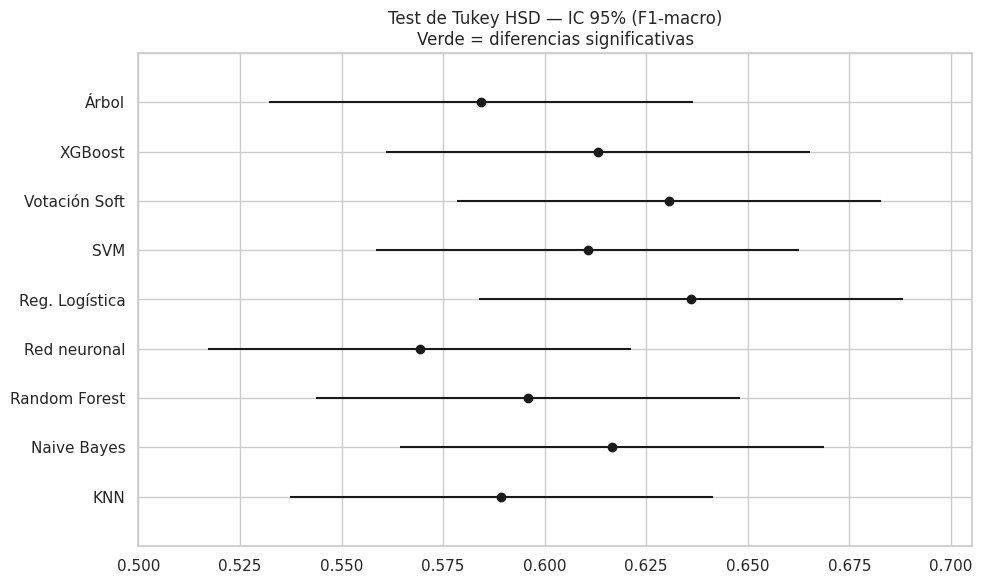

In [37]:
# Visualización Tukey
fig, ax = plt.subplots(figsize=(10, 6))
tukey.plot_simultaneous(ax=ax)
ax.set_title('Test de Tukey HSD — IC 95% (F1-macro)\nVerde = diferencias significativas', fontsize=12)
ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [38]:
# ── Friedman + Nemenyi (alternativa no paramétrica) ──────────────────────
data_friedman = [comparacion_CV[col].values for col in comparacion_CV.columns]
friedman_stat, friedman_p = stats.friedmanchisquare(*data_friedman)

print('=== Test de Friedman ===')
print(f'Estadístico de Friedman : {friedman_stat:.4f}')
print(f'p-valor                  : {friedman_p:.6f}')

if friedman_p < 0.05:
    print('\n✅ p < 0.05 → diferencias significativas. Procedemos con Nemenyi.')
    df_nemenyi = pd.DataFrame(
        np.array(data_friedman).T,
        columns=comparacion_CV.columns
    )
    nemenyi = sp.posthoc_nemenyi_friedman(df_nemenyi)
    nemenyi.columns = comparacion_CV.columns
    nemenyi.index   = comparacion_CV.columns

    print('\n=== Test de Nemenyi — p-valores por pares (TABLA COMPLETA) ===')
    print('Valores < 0.05 indican diferencia significativa entre el par de modelos')
    display(nemenyi.round(4).style
            .applymap(lambda v: 'background-color: lightgreen'
                      if isinstance(v, float) and v < 0.05 else ''))
else:
    print('\n⚠️  p ≥ 0.05 → sin diferencias significativas.')
    print('Se selecciona el modelo con mejor promedio o menor complejidad computacional.')

=== Test de Friedman ===
Estadístico de Friedman : 11.5832
p-valor                  : 0.170792

⚠️  p ≥ 0.05 → sin diferencias significativas.
Se selecciona el modelo con mejor promedio o menor complejidad computacional.


=== Ranking de modelos por F1-macro medio (CV) ===
Reg. Logística    0.6360
Votación Soft     0.6306
Naive Bayes       0.6166
XGBoost           0.6132
SVM               0.6106
Random Forest     0.5959
KNN               0.5893
Árbol             0.5844
Red neuronal      0.5692

TOP 3 seleccionados: ['Reg. Logística', 'Votación Soft', 'Naive Bayes']


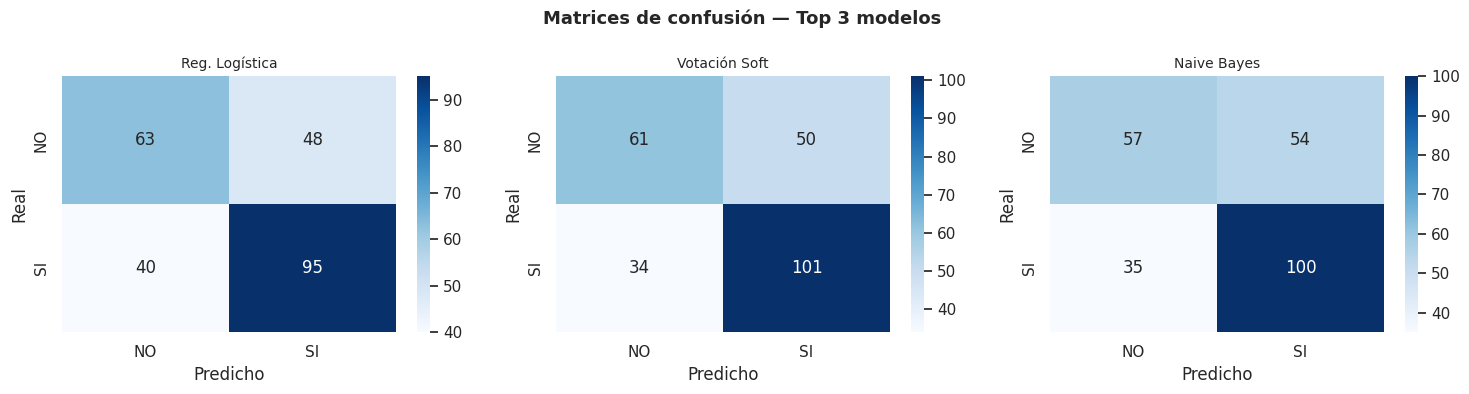

In [39]:
# Selección del top 3 por F1-macro medio en CV
ranking = comparacion_CV.mean().sort_values(ascending=False)
print('=== Ranking de modelos por F1-macro medio (CV) ===')
print(ranking.round(4).to_string())

top3 = ranking.head(3).index.tolist()
print(f'\nTOP 3 seleccionados: {top3}')

# Matrices de confusión del top 3
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, nombre in zip(axes, top3):
    modelo = modelos_dict.get(nombre)
    if modelo is None: continue
    Y_pred = modelo.predict(X_test)
    cm = confusion_matrix(Y_test, Y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labelencoder.classes_,
                yticklabels=labelencoder.classes_)
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
plt.suptitle('Matrices de confusión — Top 3 modelos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 7. Hiperparametrización de los 3 mejores modelos

**a) GridSearchCV**: búsqueda exhaustiva sobre grilla predefinida.

**b) Optimización bayesiana con Optuna (TPE)**: guía la búsqueda hacia
regiones prometedoras usando resultados previos. Equivalente conceptual
a algoritmos genéticos pero más eficiente al explotar historia de evaluaciones.

In [40]:
grids = {
    'Reg. Logística': {
        'C':            [0.001, 0.01, 0.1, 1, 10, 100],
        'solver':       ['lbfgs', 'liblinear'],
        'class_weight': ['balanced', None],
    },


    'Naive Bayes': {
        'alpha':     [0.01, 0.1, 0.5, 1.0, 2.0, 5.0],
        'binarize':  [0.0, 0.3, 0.5],
        'fit_prior': [True, False],
    },


        'Votación Soft': {
    'weights':                 [(3,2,1), (2,2,1), (1,1,1), (3,1,1), (2,3,1)],

    'lr__C':                   [0.01, 0.1, 1.0, 10.0],
    'lr__class_weight':        ['balanced', None],

    'nb__alpha':               [0.01, 0.1, 1.0, 5.0],
    'nb__fit_prior':           [True, False],

    'xgb__n_estimators':  [50, 80, 150],
    'xgb__max_depth':     [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
}


}

modelos_base = {
    'Reg. Logística': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'KNN':            KNeighborsClassifier(),
    'Árbol':          DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Naive Bayes':    BernoulliNB(),
    'Random Forest':  RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE),
    'XGBoost':        XGBClassifier(scale_pos_weight=scale_pos, eval_metric='logloss',
                                    verbosity=0, n_jobs=-1, random_state=RANDOM_STATE),
    'Votación Soft':  VotingClassifier(
    estimators=[('lr', model_lr), ('nb', model_nb), ('xgb', model_xgb)],
    voting='soft'),
}
print('Grillas definidas.')

Grillas definidas.


In [41]:
# ── A) GRIDSEARCHCV ──────────────────────────────────────────────────────
print('=== GridSearchCV — Top 3 modelos ===\n')
mejores_grid = {}

for nombre in top3:
    if not grids.get(nombre):
        print(f'{nombre}: sin grilla → se conserva modelo actual.')
        mejores_grid[nombre] = modelos_dict[nombre]
        continue

    print(f'Búsqueda: {nombre}...')
    gs = GridSearchCV(modelos_base[nombre], grids[nombre],
                      cv=cv, scoring='f1_macro', n_jobs=-1, refit=True, verbose=0)
    gs.fit(X_train, Y_train)
    mejores_grid[nombre] = gs.best_estimator_

    Y_pred = gs.best_estimator_.predict(X_test)
    print(f'  Mejores parámetros: {gs.best_params_}')
    print(f'  F1-macro CV  : {gs.best_score_:.4f}')
    print(metrics.classification_report(Y_test, Y_pred,
                                        target_names=labelencoder.classes_))


=== GridSearchCV — Top 3 modelos ===

Búsqueda: Reg. Logística...
  Mejores parámetros: {'C': 0.1, 'class_weight': 'balanced', 'solver': 'liblinear'}
  F1-macro CV  : 0.6430
              precision    recall  f1-score   support

          NO       0.62      0.56      0.59       111
          SI       0.66      0.72      0.69       135

    accuracy                           0.65       246
   macro avg       0.64      0.64      0.64       246
weighted avg       0.64      0.65      0.64       246

Búsqueda: Votación Soft...
  Mejores parámetros: {'lr__C': 1.0, 'lr__class_weight': 'balanced', 'nb__alpha': 1.0, 'nb__fit_prior': True, 'weights': (3, 1, 1), 'xgb__learning_rate': 0.05, 'xgb__max_depth': 3, 'xgb__n_estimators': 80}
  F1-macro CV  : 0.6479
              precision    recall  f1-score   support

          NO       0.64      0.56      0.60       111
          SI       0.67      0.74      0.70       135

    accuracy                           0.66       246
   macro avg       0.66 

In [42]:
# ── B) OPTIMIZACIÓN BAYESIANA — OPTUNA ───────────────────────────────────
import optuna

def get_objective(nombre, X_tr, Y_tr, cv_):
    def objective(trial):
        if nombre == 'Reg. Logística':
            m = LogisticRegression(
                C=trial.suggest_float('C', 1e-4, 1e2, log=True),
                solver=trial.suggest_categorical('solver', ['lbfgs','liblinear']),
                penalty='l2', max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)

        elif nombre == 'Naive Bayes':
            m = BernoulliNB(
                alpha=trial.suggest_float('alpha', 0.01, 5.0),
                binarize=trial.suggest_float('binarize', 0.0, 0.5),
                fit_prior=trial.suggest_categorical('fit_prior', [True, False]))
        elif nombre == 'Votación Soft':
            lr = LogisticRegression(
                C=trial.suggest_float('lr__C', 1e-4, 1e2, log=True),
                solver=trial.suggest_categorical('lr__solver', ['lbfgs', 'liblinear']),
                penalty='l2', max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)

            nb = BernoulliNB(
                alpha=trial.suggest_float('nb__alpha', 0.01, 5.0),
                binarize=trial.suggest_float('nb__binarize', 0.0, 0.5),
                fit_prior=trial.suggest_categorical('nb__fit_prior', [True, False]))

            xgb = XGBClassifier(
                n_estimators=trial.suggest_int('xgb__n_estimators', 50, 200),
                max_depth=trial.suggest_int('xgb__max_depth', 3, 7),
                learning_rate=trial.suggest_float('xgb__learning_rate', 0.01, 0.3, log=True),
                subsample=trial.suggest_float('xgb__subsample', 0.6, 1.0),
                colsample_bytree=trial.suggest_float('xgb__colsample_bytree', 0.6, 1.0),
                scale_pos_weight=scale_pos,
                eval_metric='logloss', verbosity=0, n_jobs=-1, random_state=RANDOM_STATE)

            w1 = trial.suggest_int('w1', 1, 5)
            w2 = trial.suggest_int('w2', 1, 5)
            w3 = trial.suggest_int('w3', 1, 5)

            m = VotingClassifier(
                estimators=[('lr', lr), ('nb', nb), ('xgb', xgb)],
                voting='soft',
                weights=[w1, w2, w3])


        else:
            return 0.0
        sc = cross_validate(m, X_tr, Y_tr, cv=cv_, scoring='f1_macro', n_jobs=-1)
        return sc['test_score'].mean()
    return objective

print('=== Optimización Bayesiana (Optuna TPE) — Top 3 modelos ===\n')
mejores_optuna = {}

for nombre in top3:
    print(f'Optimizando: {nombre}...')
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(get_objective(nombre, X_train, Y_train, cv),
                   n_trials=50, show_progress_bar=False)
    mejores_optuna[f'study_{nombre}'] = study
    print(f'  Mejor F1-macro CV : {study.best_value:.4f}')
    print(f'  Mejores params    : {study.best_params}\n')

=== Optimización Bayesiana (Optuna TPE) — Top 3 modelos ===

Optimizando: Reg. Logística...
  Mejor F1-macro CV : 0.6477
  Mejores params    : {'C': 0.12647598951788191, 'solver': 'liblinear'}

Optimizando: Votación Soft...
  Mejor F1-macro CV : 0.6406
  Mejores params    : {'lr__C': 0.6143903801278888, 'lr__solver': 'liblinear', 'nb__alpha': 4.3337045697836105, 'nb__binarize': 0.09129054219499647, 'nb__fit_prior': True, 'xgb__n_estimators': 51, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.07950994814573775, 'xgb__subsample': 0.6467840955841518, 'xgb__colsample_bytree': 0.9359215470238137, 'w1': 5, 'w2': 3, 'w3': 2}

Optimizando: Naive Bayes...
  Mejor F1-macro CV : 0.6263
  Mejores params    : {'alpha': 3.009563908598612, 'binarize': 0.35403628889802274, 'fit_prior': False}



In [43]:
#Optimización con algoritmos genéticos
!pip install sklearn-genetic-opt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 28.0 MB/s eta 0:00:00


In [44]:
from sklearn_genetic import GASearchCV
from sklearn_genetic.space import Continuous, Categorical, Integer
from sklearn_genetic.plots import plot_fitness_evolution, plot_search_space
from sklearn.model_selection import StratifiedKFold


# Grid para regresión logística
param_grid_Reg_logistica = {
    'C':            Continuous(0.0001, 1000),
    'solver':       Categorical(['lbfgs', 'liblinear']),
    'class_weight': Categorical(['balanced', None]),
}


evolved_estimator_regresionLogistica = GASearchCV(estimator=model_lr,
                               cv=10, #10 debería hacerse con 10 folds
                               scoring='f1_macro', #maximiza scoring, corrected from 'f1-score'
                               population_size=20, #tamaño de la población es constante
                               generations=35, #generaciones o iteraciones
                               elitism=True, #selección de padres
                               crossover_probability=0.4, #porcentaje para hacer recombinación
                               mutation_probability=0.6, #porcentaje de mutación
                               param_grid=param_grid_Reg_logistica,
                               criteria='max',
                               verbose=True)

In [45]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

medidas = {}

#Aprendizaje
evolved_estimator_regresionLogistica.fit(X_train,Y_train) #70%

Y_pred_regresionLogistica = evolved_estimator_regresionLogistica.best_estimator_.predict(X_test)
medidas['Genetics_regresionLogistica'] = [
    accuracy_score(Y_test, Y_pred_regresionLogistica),
    f1_score(Y_test, Y_pred_regresionLogistica, average='macro'),
    precision_score(Y_test, Y_pred_regresionLogistica, average='macro'),
    recall_score(Y_test, Y_pred_regresionLogistica, average='macro')
]

gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	20    	0.610026	0.00435397 	0.614483   	0.605124   
1  	40    	0.614112	0.000813399	0.614486   	0.610967   
2  	40    	0.614204	0.000517926	0.614483   	0.612662   
3  	40    	0.614408	7.49779e-05	0.614483   	0.614333   
4  	40    	0.614423	7.34631e-05	0.614483   	0.614333   
5  	40    	0.614446	6.49328e-05	0.614483   	0.614333   
6  	40    	0.614377	0.000396117	0.614483   	0.612662   
7  	40    	0.614483	2.22045e-16	0.614483   	0.614483   
8  	40    	0.614484	5.2482e-07 	0.614486   	0.614483   
9  	40    	0.614484	1.04271e-06	0.614486   	0.614483   
10 	40    	0.614485	1.19799e-06	0.614486   	0.614483   
11 	40    	0.614478	3.31103e-05	0.614486   	0.614333   
12 	40    	0.614478	3.31595e-05	0.614486   	0.614333   
13 	40    	0.614394	0.000397507	0.614486   	0.612662   
14 	40    	0.614295	0.000549062	0.614486   	0.612639   
15 	40    	0.614478	3.32069e-05	0.614486   	0.614333   
16 	40    	0.614486	0          	0.614486   	0.61

In [46]:
# Mejor modelo de Naive Bayes
best_params_regresionLogistica = evolved_estimator_regresionLogistica.best_params_
genetics_best_model_regresionLogistica = evolved_estimator_regresionLogistica.best_estimator_
print(best_params_regresionLogistica)

print(classification_report(Y_test, Y_pred_regresionLogistica, target_names=labelencoder.classes_))
print(confusion_matrix(Y_test, Y_pred))

{'C': np.float64(838.4914380784568), 'solver': 'lbfgs', 'class_weight': 'balanced'}
              precision    recall  f1-score   support

          NO       0.65      0.59      0.62       111
          SI       0.68      0.74      0.71       135

    accuracy                           0.67       246
   macro avg       0.67      0.66      0.66       246
weighted avg       0.67      0.67      0.67       246

[[64 47]
 [40 95]]


In [47]:
#Algoritmo genético para Naive Bayes

param_grid_Naive = {
    'alpha':     Continuous(0.01, 5.0),
    'binarize':  Categorical([None]),
    'fit_prior': Categorical([True, False]),
}

evolved_estimator_Naive = GASearchCV(estimator=model_nb,
                               cv=10, #10 debería hacerse con 10 folds
                               scoring='f1_macro', #maximiza scoring, corrected from 'f1-score'
                               population_size=20, #tamaño de la población es constante
                               generations=35, #generaciones o iteraciones
                               elitism=True, #selección de padres
                               crossover_probability=0.4, #porcentaje para hacer recombinación
                               mutation_probability=0.6, #porcentaje de mutación
                               param_grid=param_grid_Naive,
                               criteria='max',
                               verbose=True)

In [48]:
#Aprendizaje
evolved_estimator_Naive.fit(X_train,Y_train) #70%

gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	20    	0.589301	0.00668623 	0.597793   	0.577984   
1  	40    	0.595174	0.00211261 	0.597793   	0.591007   
2  	40    	0.596622	0.00180413 	0.597793   	0.592016   
3  	40    	0.597564	0.000701663	0.597793   	0.594821   
4  	40    	0.597793	1.11022e-16	0.597793   	0.597793   
5  	40    	0.59786 	0.00104163 	0.599839   	0.594149   
6  	40    	0.598385	0.000694415	0.599839   	0.597793   
7  	40    	0.598974	0.000879921	0.599839   	0.595688   
8  	40    	0.599365	0.00048045 	0.599839   	0.597759   
9  	40    	0.599637	0.000274158	0.599839   	0.599264   
10 	40    	0.59981 	0.000125273	0.599839   	0.599264   
11 	40    	0.599839	1.11022e-16	0.599839   	0.599839   
12 	40    	0.599839	1.11022e-16	0.599839   	0.599839   
13 	40    	0.599554	0.00124005 	0.599839   	0.594149   
14 	40    	0.599839	1.11022e-16	0.599839   	0.599839   
15 	40    	0.599249	0.00257113 	0.599839   	0.588041   
16 	40    	0.599839	1.11022e-16	0.599839   	0.59

GASearchCV(crossover_probability=0.4, cv=10,
           estimator=BernoulliNB(alpha=np.float64(0.09616266391467367),
                                 binarize=None),
           generations=35, mutation_probability=0.6,
           param_grid={'alpha': <sklearn_genetic.space.space.Continuous object at 0x7d84aa7fcd10>,
                       'binarize': <sklearn_genetic.space.space.Categorical object at 0x7d84aa796a80>,
                       'fit_prior': <sklearn_genetic.space.space.Categorical object at 0x7d84aa7d61b0>},
           population_size=20, return_train_score=True, scoring='f1_macro',
           warm_start_configs=[])

In [49]:
# Mejor modelo de Naive Bayes
best_params_Naive = evolved_estimator_Naive.best_params_
genetics_best_model_Naive = evolved_estimator_Naive.best_estimator_
print(best_params_Naive)


# Evaluación
Y_pred_nb = evolved_estimator_Naive.best_estimator_.predict(X_test)
medidas['Genetics_NB'] = [
    accuracy_score(Y_test, Y_pred_nb),
    f1_score(Y_test, Y_pred_nb, average='macro'),
    precision_score(Y_test, Y_pred_nb, average='macro'),
    recall_score(Y_test, Y_pred_nb, average='macro')
]

print(classification_report(Y_test, Y_pred_nb, target_names=labelencoder.classes_))
print(confusion_matrix(Y_test, Y_pred))

{'alpha': np.float64(0.09616266391467367), 'binarize': None, 'fit_prior': True}
              precision    recall  f1-score   support

          NO       0.62      0.52      0.57       111
          SI       0.65      0.74      0.69       135

    accuracy                           0.64       246
   macro avg       0.64      0.63      0.63       246
weighted avg       0.64      0.64      0.64       246

[[64 47]
 [40 95]]


In [50]:
# VotingClassifier como estimador base
model_soft = VotingClassifier(
    estimators=[('lr', model_lr), ('nb', model_nb), ('xgb', model_xgb)],
    voting='soft'
)

param_grid_voting = {
    'weights': Categorical([(3,2,1), (2,2,1), (1,1,1), (3,1,1), (2,3,1)]),

    'lr__C':            Continuous(0.01, 10.0),
    'lr__class_weight': Categorical(['balanced', None]),

    'nb__alpha':        Continuous(0.01, 5.0),
    'nb__binarize':     Continuous(0.0, 0.5),
    'nb__fit_prior':    Categorical([True, False]),

    'xgb__n_estimators':   Integer(50, 200),
    'xgb__max_depth':      Integer(3, 7),
    'xgb__learning_rate':  Continuous(0.01, 0.3),
    'xgb__subsample':      Continuous(0.6, 1.0),
    'xgb__colsample_bytree': Continuous(0.6, 1.0),
}
# GASearchCV apuntando al VotingClassifier
evolved_estimator_voting = GASearchCV(
    estimator=model_soft,       # <-- ahora es el VotingClassifier
    cv=3,
    scoring='f1',               # sklearn usa 'f1', no 'f1-score'
    population_size=20,
    generations=35,
    elitism=True,
    crossover_probability=0.4,
    mutation_probability=0.6,
    param_grid=param_grid_voting,
    criteria='max',
    verbose=True
)

evolved_estimator_voting.fit(X_train, Y_train)

gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	20    	0.646823	0.00754035 	0.659193   	0.631622   
1  	40    	0.654238	0.00535746 	0.661481   	0.641968   
2  	40    	0.658102	0.00372641 	0.662831   	0.648343   
3  	40    	0.660016	0.00147546 	0.662831   	0.657965   
4  	40    	0.661197	0.0014434  	0.664418   	0.659193   
5  	40    	0.66209 	0.00128799 	0.664418   	0.658435   
6  	40    	0.663178	0.00122887 	0.664426   	0.660744   
7  	40    	0.663826	0.00144675 	0.666146   	0.659193   
8  	40    	0.664651	0.000659809	0.666648   	0.66383    
9  	40    	0.665245	0.00101927 	0.666677   	0.664418   
10 	40    	0.665781	0.000952009	0.666677   	0.664433   
11 	40    	0.666422	0.000541842	0.666677   	0.66444    
12 	40    	0.666605	0.000191389	0.666677   	0.665829   
13 	40    	0.66653 	0.00034159 	0.666677   	0.665324   
14 	40    	0.66629 	0.00192091 	0.668595   	0.658211   
15 	40    	0.667268	0.00212051 	0.676061   	0.665471   
16 	40    	0.668558	0.00289533 	0.676061   	0.66

GASearchCV(crossover_probability=0.4,
           estimator=VotingClassifier(estimators=[('lr',
                                                   LogisticRegression(C=np.float64(0.8578989421574561),
                                                                      max_iter=1000,
                                                                      random_state=42)),
                                                  ('nb',
                                                   BernoulliNB(alpha=np.float64(1.7271016936879588),
                                                               binarize=np.float64(0.3449270375564067))),
                                                  ('xgb',
                                                   XGBClassifier(base_score=None,
                                                                 booster=None,
                                                                 callbacks=None,
                                                                 colsample_bylevel=0.8,...
                       'xgb__learning_rate': <sklearn_genetic.space.space.Continuous object at 0x7d84aa7e86e0>,
                       'xgb__max_depth': <sklearn_genetic.space.space.Integer object at 0x7d84aae65670>,
                       'xgb__n_estimators': <sklearn_genetic.space.space.Integer object at 0x7d84aa7f2f00>,
                       'xgb__subsample': <sklearn_genetic.space.space.Continuous object at 0x7d84aa7ebe90>},
           population_size=20, return_train_score=True, scoring='f1',
           warm_start_configs=[])

In [51]:
# Mejor modelo de voting soft
best_params_voting = evolved_estimator_voting.best_params_
genetics_best_model_voting = evolved_estimator_voting.best_estimator_
print(best_params_voting)

# Evaluación
Y_pred_voting = evolved_estimator_voting.best_estimator_.predict(X_test)
medidas['Genetics_Voting'] = [
    accuracy_score(Y_test, Y_pred_voting),
    f1_score(Y_test, Y_pred_voting, average='macro'),
    precision_score(Y_test, Y_pred_voting, average='macro'),
    recall_score(Y_test, Y_pred_voting, average='macro')
]

print(classification_report(Y_test, Y_pred_voting, target_names=labelencoder.classes_))
print(confusion_matrix(Y_test, Y_pred_voting))

{'weights': (2, 3, 1), 'lr__C': np.float64(0.8578989421574561), 'lr__class_weight': None, 'nb__alpha': np.float64(1.7271016936879588), 'nb__binarize': np.float64(0.3449270375564067), 'nb__fit_prior': True, 'xgb__n_estimators': 103, 'xgb__max_depth': 5, 'xgb__learning_rate': np.float64(0.2258185332845812), 'xgb__subsample': np.float64(0.6571213744138834), 'xgb__colsample_bytree': np.float64(0.9471152224446856)}
              precision    recall  f1-score   support

          NO       0.66      0.51      0.58       111
          SI       0.66      0.78      0.71       135

    accuracy                           0.66       246
   macro avg       0.66      0.65      0.65       246
weighted avg       0.66      0.66      0.65       246

[[ 57  54]
 [ 30 105]]


In [52]:
modelos_finales = {}
modelos_finales['Votación Soft'] = evolved_estimator_voting.best_estimator_
modelos_finales['Reg. Logística'] = evolved_estimator_regresionLogistica.best_estimator_
modelos_finales['Naive Bayes'] = evolved_estimator_Naive.best_estimator_
resultados_finales = {}
for nombre, modelo in modelos_finales.items():
    Y_pred  = modelo.predict(X_test)
    Y_proba = modelo.predict_proba(X_test)[:, 1]
    resultados_finales[nombre] = {
        'Recall':    round(metrics.recall_score(Y_test, Y_pred, average='macro'), 4),
        'AUC-ROC':  round(roc_auc_score(Y_test, Y_proba), 4),
        'F1-macro': round(metrics.f1_score(Y_test, Y_pred, average='macro'), 4),
        'Precisión':round(metrics.precision_score(Y_test, Y_pred, average='macro'), 4),
    }

df_final = pd.DataFrame(resultados_finales).T.sort_values('Recall', ascending=False)
print('Métricas finales tras hiperparametrización:')
display(df_final.style.highlight_max(color='lightgreen'))

mejor_nombre = df_final['Recall'].idxmax()
print(f'\nMEJOR MODELO: {mejor_nombre}')

Métricas finales tras hiperparametrización:


,Recall,AUC-ROC,F1-macro,Precisión
Reg. Logística,0.663200,0.685000,0.663900,0.667500
Votación Soft,0.645600,0.683600,0.645000,0.657800
Naive Bayes,0.631600,0.678500,0.631500,0.638600



MEJOR MODELO: Reg. Logística


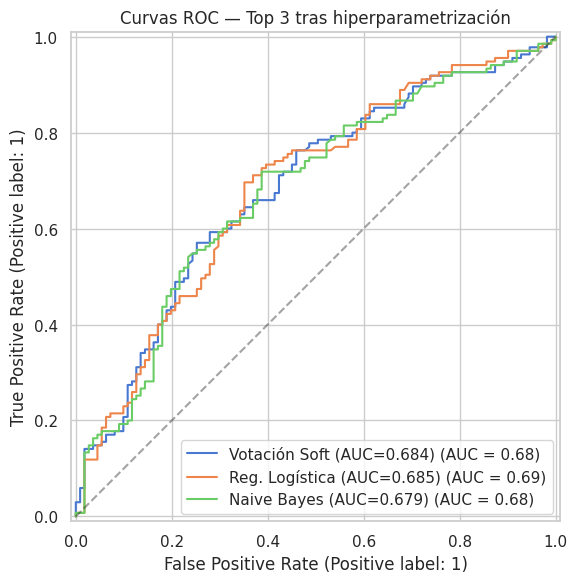

In [53]:
fig, ax = plt.subplots(figsize=(8, 6))
for nombre, modelo in modelos_finales.items():
    Y_proba = modelo.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(Y_test, Y_proba)
    RocCurveDisplay.from_predictions(Y_test, Y_proba,
                                     name=f'{nombre} (AUC={auc:.3f})', ax=ax)
ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set_title('Curvas ROC — Top 3 tras hiperparametrización', fontsize=12)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [54]:
# Evaluación final de modelos hiperparametrizados
"""
print('=== EVALUACIÓN FINAL EN TEST — modelos hiperparametrizados ===\n')
modelos_finales = {}

for nombre in top3:
    if nombre == 'Votación Soft' or f'study_{nombre}' not in mejores_optuna:
        m = mejores_grid.get(nombre, modelos_dict[nombre])
        m.fit(X_train, Y_train)
        modelos_finales[nombre] = m
        continue

    bp = mejores_optuna[f'study_{nombre}'].best_params

    if nombre == 'Reg. Logística':
        m = LogisticRegression(**bp, penalty='l2', max_iter=1000,
                               class_weight='balanced', random_state=RANDOM_STATE)

    elif nombre == 'Naive Bayes':
        m = BernoulliNB(**bp)

    elif nombre == 'XGBoost':
        m = XGBClassifier(**bp, scale_pos_weight=scale_pos, eval_metric='logloss',
                          verbosity=0, random_state=RANDOM_STATE, n_jobs=-1)

    m.fit(X_bal, Y_bal)
    modelos_finales[nombre] = m
    Y_pred = m.predict(X_test)
    print(f'{nombre}:')
    print(metrics.classification_report(Y_test, Y_pred, target_names=labelencoder.classes_))
    """

"\nprint('=== EVALUACIÓN FINAL EN TEST — modelos hiperparametrizados ===\n')\nmodelos_finales = {}\n\nfor nombre in top3:\n    if nombre == 'Votación Soft' or f'study_{nombre}' not in mejores_optuna:\n        m = mejores_grid.get(nombre, modelos_dict[nombre])\n        m.fit(X_train, Y_train)\n        modelos_finales[nombre] = m\n        continue\n\n    bp = mejores_optuna[f'study_{nombre}'].best_params\n\n    if nombre == 'Reg. Logística':\n        m = LogisticRegression(**bp, penalty='l2', max_iter=1000,\n                               class_weight='balanced', random_state=RANDOM_STATE)\n     \n    elif nombre == 'Naive Bayes':\n        m = BernoulliNB(**bp)\n   \n    elif nombre == 'XGBoost':\n        m = XGBClassifier(**bp, scale_pos_weight=scale_pos, eval_metric='logloss',\n                          verbosity=0, random_state=RANDOM_STATE, n_jobs=-1)\n\n    m.fit(X_bal, Y_bal)\n    modelos_finales[nombre] = m\n    Y_pred = m.predict(X_test)\n    print(f'{nombre}:')\n    print(metric

Comparación mejor modelo basado en optimización por algoritmos genéticos

In [55]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.model_selection import cross_val_score


# Scores por fold de cada mejor modelo
scores_lr = cross_val_score(genetics_best_model_regresionLogistica, X_train, Y_train, cv=10, scoring='f1_macro')
scores_nb = cross_val_score(genetics_best_model_Naive, X_train, Y_train, cv=10, scoring='f1_macro')
scores_voting = cross_val_score(genetics_best_model_voting, X_train, Y_train, cv=10, scoring='f1_macro')

# Tabla comparativa en test
df_medidas = pd.DataFrame(
    medidas,
    index=['Accuracy', 'F1', 'Precision', 'Recall']
)
print(df_medidas)

# ANOVA
f_stat, p_value = stats.f_oneway(scores_lr, scores_nb, scores_voting)
print(f'\nANOVA: F={f_stat:.4f}, p={p_value:.4f}')

if p_value < 0.05:
    print('Hay diferencias significativas entre los modelos (p < 0.05)')
else:
    print('No hay diferencias significativas entre los modelos (p >= 0.05)')

# Tukey HSD
all_scores = np.concatenate([scores_lr, scores_nb, scores_voting])
labels = ['LR']*10 + ['NB']*10 + ['Voting']*10

tukey = pairwise_tukeyhsd(all_scores, labels, alpha=0.05)
print('\nTukey HSD:')
print(tukey)

# Mejor modelo por F1 en test
mejor = df_medidas.loc['F1'].idxmax()
print(f'\nMejor modelo por F1 en test: {mejor}')

           Genetics_regresionLogistica  Genetics_NB  Genetics_Voting
Accuracy                      0.670732     0.642276         0.658537
F1                            0.663929     0.631536         0.645022
Precision                     0.667466     0.638625         0.657775
Recall                        0.663163     0.631632         0.645646

ANOVA: F=0.0678, p=0.9346
No hay diferencias significativas entre los modelos (p >= 0.05)

Tukey HSD:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    LR     NB  -0.0135  0.929 -0.1052 0.0781  False
    LR Voting  -0.0055 0.9877 -0.0972 0.0861  False
    NB Voting    0.008 0.9746 -0.0837 0.0996  False
---------------------------------------------------

Mejor modelo por F1 en test: Genetics_regresionLogistica


##Entrenamiento del mejor modelo

In [56]:
modelo_final=genetics_best_model_regresionLogistica.fit(X,Y)

# 8. Guardar el mejor modelo

In [57]:

variables = X.columns.values

artefacto = [modelo_final, labelencoder, variables]

filename = 'modelo_reincidencia.pkl'
with open(filename, 'wb') as f:
    pickle.dump(artefacto, f)

# Verificación
with open(filename, 'rb') as f:
    modelo_c, le_c, vars_c = pickle.load(f)

Y_check = modelo_c.predict(X_test)
print(f'Modelo guardado: {filename}')
print(f'Verificación — F1-macro: {metrics.f1_score(Y_test, Y_check, average="macro"):.4f}')
print(f'\nArtefacto guardado:')
print(f'  [0] modelo:        {modelo_final}')
print(f'  [1] labelencoder:  clases = {le_c.classes_}')
print(f'  [2] variables:     {len(vars_c)} columnas')

Modelo guardado: modelo_reincidencia.pkl
Verificación — F1-macro: 0.6762

Artefacto guardado:
  [0] modelo:        LogisticRegression(C=np.float64(0.8578989421574561), max_iter=1000,
                   random_state=42)
  [1] labelencoder:  clases = ['NO' 'SI']
  [2] variables:     53 columnas
